## 04. Clustering Experiments & Customer Segmentation

### Objective

The objective of this notebook is to identify a meaningful and stable segmentation of customers based on their purchasing behavior.

The previous analysis produced several candidate representations:

1. Standard-scaled original customer features
2. Robust-scaled original customer features
3. StandardScaler + PCA
4. RobustScaler + PCA

These representations will be evaluated using multiple clustering algorithms.

Because this is an **unsupervised learning problem**, there is no ground-truth target variable that can be used for conventional supervised cross-validation.

Instead, clustering quality will be evaluated using:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- Cluster-size distribution
- Stability across different initializations
- Visualization
- Behavioral separation
- Business interpretability

The final clustering solution will be selected based on the combination of these criteria rather than a single metric.

### Import Required Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

### Load Preprocessed Feature Matrices

To begin our clustering experiments, we must first ingest the transformed data generated in our previous pipeline step (`03_preprocessing_pca.ipynb`). 

By loading these saved matrices, we decouple our clustering environment from the heavy data-wrangling steps, allowing for rapid iteration and experimentation. We are loading two distinct representations to evaluate how different scaling techniques impact the performance of our clustering algorithms:

* **`X_standard`:** Features centered and scaled using Z-score standardization (Mean = 0, Variance = 1).
* **`X_robust`:** Features scaled using the median and Interquartile Range (IQR), which limits the mathematical influence of extreme customer outliers

*Note: We explicitly pass `index_col='CustomerID'` during ingestion to preserve our user identities, ensuring that the final cluster labels can be mapped accurately back to specific customers.*

In [11]:
X_standard = pd.read_csv('../data/processed/X_standard.csv', index_col='Customer ID')
X_robust = pd.read_csv('../data/processed/X_robust.csv', index_col='Customer ID')

representations = {
    "Standard (Base)": X_standard,
    "Robust (Base)": X_robust,
}

### Candidate PCA Representations

**PCA** will be treated as a candidate modeling representation rather than an automatic improvement.

The purpose of PCA is to:

- reduce dimensionality
- create uncorrelated principal components
- potentially reduce redundancy
- provide a lower-dimensional representation

*However, PCA can also discard information that may be useful for customer segmentation.*

Therefore, clustering will be compared in both:

- original scaled feature space
- PCA space

The **number of PCA components** used for modeling is based on the **previous PCA analysis** rather than assuming that 95% explained variance is always optimal.

In [12]:
pca_components = [3, 4, 5, 6]

for n in pca_components:
    pca_std = PCA(n_components=n, random_state=42)
    representations[f"Standard + PCA ({n})"] = pd.DataFrame(
        pca_std.fit_transform(X_standard), index=X_standard.index
    )
    
    pca_rob = PCA(n_components=n, random_state=42)
    representations[f"Robust + PCA ({n})"] = pd.DataFrame(
        pca_rob.fit_transform(X_robust), index=X_robust.index
    )

for name, data in representations.items():
    print(f'{name:<22}: {data.shape}')

Standard (Base)       : (5878, 11)
Robust (Base)         : (5878, 11)
Standard + PCA (3)    : (5878, 3)
Robust + PCA (3)      : (5878, 3)
Standard + PCA (4)    : (5878, 4)
Robust + PCA (4)      : (5878, 4)
Standard + PCA (5)    : (5878, 5)
Robust + PCA (5)      : (5878, 5)
Standard + PCA (6)    : (5878, 6)
Robust + PCA (6)      : (5878, 6)


### Baseline K-Means Search

We will use K-Means as our baseline algorithm to evaluate cluster counts ($k \in [2, 8]$) across all four data representations. We track the following metrics:
* **Inertia (Elbow Method):** Measures intra-cluster variance (lower is better).
* **Silhouette Score:** Measures cluster cohesion and separation (closer to 1 is better).
* **Davies-Bouldin Index:** Measures similarity between clusters (lower is better).
* **Calinski-Harabasz Index:** Measures ratio of between-cluster variance to within-cluster variance (higher is better).

In [13]:
k_range = range(2, 9)
results = []

for rep_name, X_data in representations.items():
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_data)
        
        results.append({
            "Representation": rep_name,
            "k": k,
            "Inertia": kmeans.inertia_,
            "Silhouette": silhouette_score(X_data, labels),
            "Davies-Bouldin": davies_bouldin_score(X_data, labels),
            "Calinski-Harabasz": calinski_harabasz_score(X_data, labels)
        })

results_df = pd.DataFrame(results)

### Clustering Representation Findings

*The experiments show that the choice of feature representation has a substantial
impact on clustering quality.*

The **Robust-scaled** representation **combined with PCA** produced the strongest
overall clustering structure among the tested representations.

In particular, ***the Robust + PCA(3)*** representation consistently achieved
**higher Silhouette Scores, lower Davies-Bouldin Indices, and stronger
Calinski-Harabasz Scores** than most alternative representations.

Increasing the number of PCA components did not consistently improve
clustering performance. In fact, the three-component representation generally
provided the strongest results, suggesting that a compact representation
captures the most useful structure for this segmentation problem.

Although **K=2** produced the highest Silhouette Score, it may provide a
segmentation that is too coarse for the business objective. Therefore,
**K=3, K=5**, and potentially **K=6** should be investigated further rather than
selecting K solely from the maximum Silhouette Score.

**The final number of clusters will be selected after examining cluster sizes,
stability, silhouette distributions, behavioral separation, and business
interpretability**.

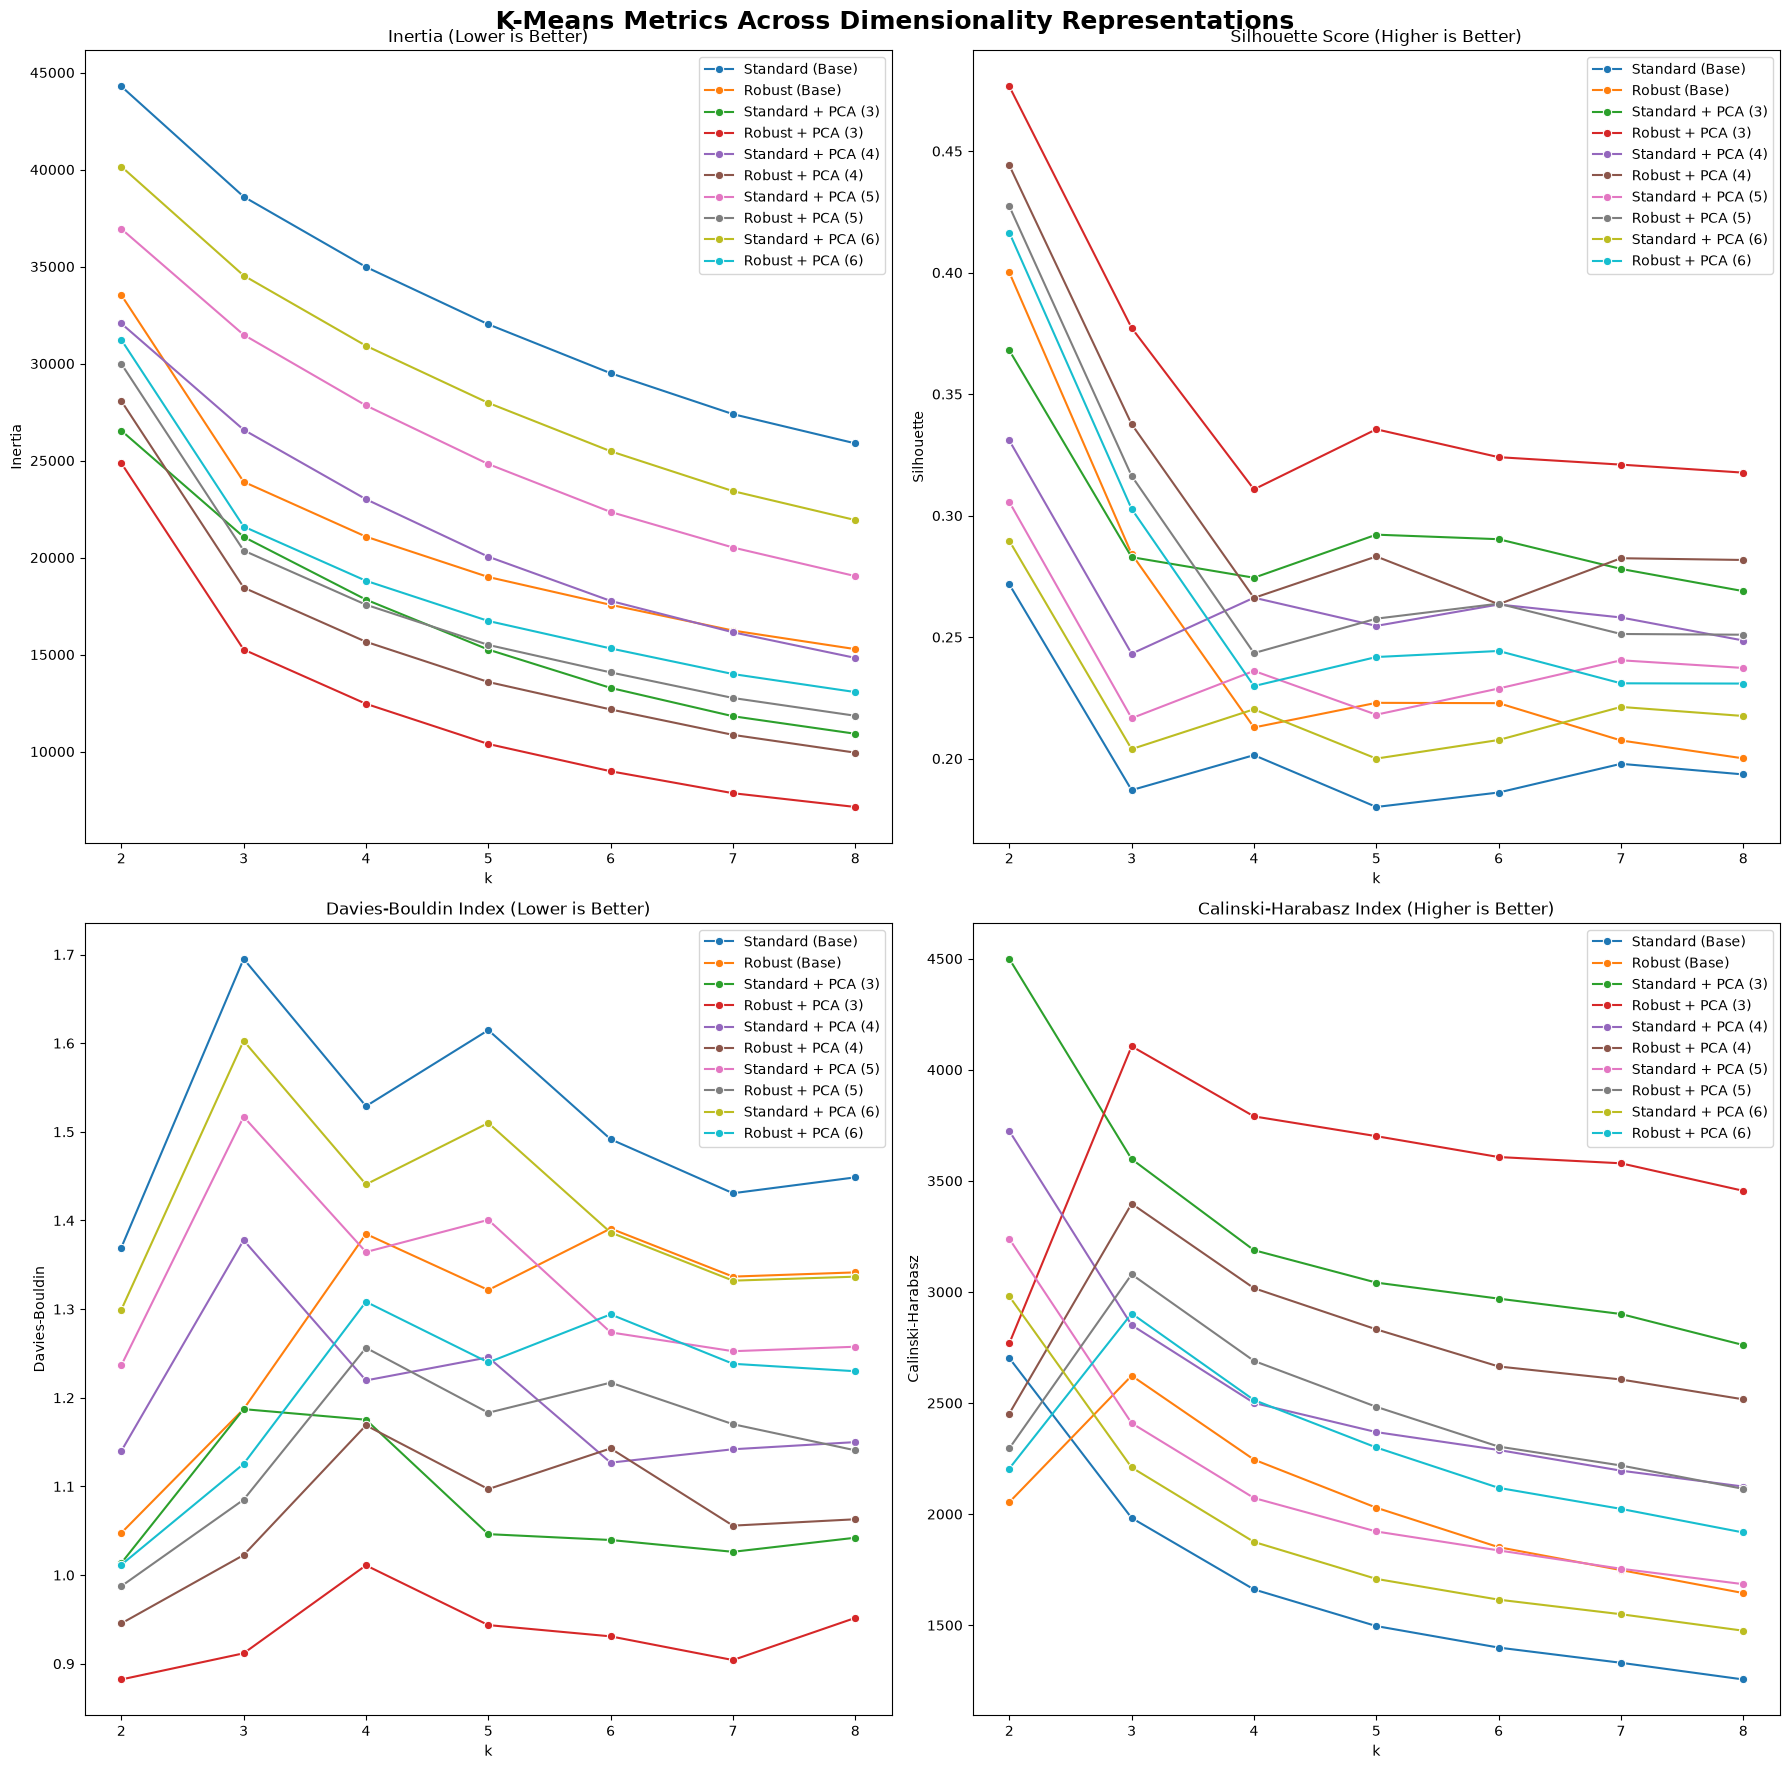

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 18))
fig.suptitle("K-Means Metrics Across Dimensionality Representations", fontsize=18, fontweight='bold')

palette = sns.color_palette("tab10", n_colors=len(representations))

sns.lineplot(data=results_df, x="k", y="Inertia", hue="Representation", marker="o", palette=palette, ax=axes[0, 0])
axes[0, 0].set_title("Inertia (Lower is Better)")
axes[0, 0].legend(loc='upper right')

sns.lineplot(data=results_df, x="k", y="Silhouette", hue="Representation", marker="o", palette=palette, ax=axes[0, 1])
axes[0, 1].set_title("Silhouette Score (Higher is Better)")
axes[0, 1].legend(loc='upper right')

sns.lineplot(data=results_df, x="k", y="Davies-Bouldin", hue="Representation", marker="o", palette=palette, ax=axes[1, 0])
axes[1, 0].set_title("Davies-Bouldin Index (Lower is Better)")
axes[1, 0].legend(loc='upper right')

sns.lineplot(data=results_df, x="k", y="Calinski-Harabasz", hue="Representation", marker="o", palette=palette, ax=axes[1, 1])
axes[1, 1].set_title("Calinski-Harabasz Index (Higher is Better)")
axes[1, 1].legend(loc='upper right')

plt.tight_layout()

### Select the Leading Representation

The previous representation experiments identified Robust + PCA as the leading
candidate.

All algorithm families below will be compared on the same representation for
a fair model-family comparison.

In [15]:
SELECTED_REPRESENTATION = "Robust + PCA (3)"

X_best = representations[SELECTED_REPRESENTATION]

print('Candidate representation -> ', SELECTED_REPRESENTATION)
print('Shape:', X_best.shape)

Candidate representation ->  Robust + PCA (3)
Shape: (5878, 3)


### Common Evaluation Function

All clustering algorithms use the same three internal metrics:

- Silhouette: higher is better
- Davies-Bouldin: lower is better
- Calinski-Harabasz: higher is better

For DBSCAN, noise points (`-1`) are excluded from the three metrics and the
noise fraction is reported separately.

In [16]:
def evaluate_clustering(X, labels, exclude_noise=True):
    X = np.asarray(X)
    labels = np.asarray(labels)

    noise_fraction = np.mean(labels == -1)

    if exclude_noise:
        mask = labels != -1
        X_eval = X[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X
        labels_eval = labels

    n_clusters = len(np.unique(labels_eval))

    if n_clusters < 2:
        return {
            "Silhouette": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan,
            "n_clusters": n_clusters,
            "noise_fraction": noise_fraction,
        }

    return {
        "Silhouette": silhouette_score(X_eval, labels_eval),
        "Davies-Bouldin": davies_bouldin_score(X_eval, labels_eval),
        "Calinski-Harabasz": calinski_harabasz_score(X_eval, labels_eval),
        "n_clusters": n_clusters,
        "noise_fraction": noise_fraction,
    }

### Complete Agglomerative Search

Search space:

- `K = 3 ... 8`
- `linkage = ward, complete, average`

In [17]:
agglomerative_results = []

for linkage in ["ward", "complete", "average"]:
    for k in range(3, 9):

        model = AgglomerativeClustering(
            n_clusters=k,
            linkage=linkage
        )

        labels = model.fit_predict(X_best)
        metrics = evaluate_clustering(X_best, labels)

        agglomerative_results.append({
            "Model": "Agglomerative",
            "Representation": SELECTED_REPRESENTATION,
            "k": k,
            "Parameters": f"linkage={linkage}",
            **metrics
        })

agglomerative_results_df = pd.DataFrame(agglomerative_results)

display(
    agglomerative_results_df
    .sort_values(["Silhouette", "Davies-Bouldin"], ascending=[False, True])
    .reset_index(drop=True)
)

,Model,Representation,k,Parameters,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,noise_fraction
0,Agglomerative,Robust + PCA (3),3,linkage=average,0.529963,0.522260,1078.960767,3,0.0
1,Agglomerative,Robust + PCA (3),4,linkage=average,0.459801,0.583961,757.683671,4,0.0
2,Agglomerative,Robust + PCA (3),5,linkage=average,0.368065,0.579735,794.496664,5,0.0
3,Agglomerative,Robust + PCA (3),6,linkage=average,0.351469,0.548209,637.211341,6,0.0
4,Agglomerative,Robust + PCA (3),4,linkage=ward,0.345937,0.989585,3135.283009,4,0.0
5,Agglomerative,Robust + PCA (3),3,linkage=ward,0.332424,0.995843,3022.864730,3,0.0
6,Agglomerative,Robust + PCA (3),5,linkage=ward,0.315753,0.965119,3310.920358,5,0.0
7,Agglomerative,Robust + PCA (3),6,linkage=ward,0.272712,0.987359,3066.539253,6,0.0
8,Agglomerative,Robust + PCA (3),7,linkage=ward,0.266550,1.090987,2930.114687,7,0.0
9,Agglomerative,Robust + PCA (3),8,linkage=ward,0.260670,1.109813,2766.095984,8,0.0


In [18]:
best_agglomerative = (
    agglomerative_results_df
    .sort_values(["Silhouette", "Davies-Bouldin"], ascending=[False, True])
    .iloc[0]
)

print("Best Agglomerative candidate:")
display(best_agglomerative.to_frame().T)

Best Agglomerative candidate:


,Model,Representation,k,Parameters,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,noise_fraction
12,Agglomerative,Robust + PCA (3),3,linkage=average,0.529963,0.52226,1078.960767,3,0.0


### Complete GMM Search

Search space:

- `K = 3 ... 8`
- `covariance_type = full, tied, diag, spherical`

In [19]:
gmm_results = []

for covariance_type in ["full", "tied", "diag", "spherical"]:
    for k in range(3, 9):

        model = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            n_init=10,
            random_state=42
        )

        labels = model.fit_predict(X_best)
        metrics = evaluate_clustering(X_best, labels)

        gmm_results.append({
            "Model": "GMM",
            "Representation": SELECTED_REPRESENTATION,
            "k": k,
            "Parameters": f"covariance={covariance_type}",
            **metrics,
            "BIC": model.bic(X_best),
            "AIC": model.aic(X_best)
        })

gmm_results_df = pd.DataFrame(gmm_results)

display(
    gmm_results_df
    .sort_values(["Silhouette", "Davies-Bouldin"], ascending=[False, True])
    .reset_index(drop=True)
)

,Model,Representation,k,Parameters,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,noise_fraction,BIC,AIC
0,GMM,Robust + PCA (3),3,covariance=spherical,0.373314,0.904182,4037.743359,3,0.0,57283.047953,57189.542347
1,GMM,Robust + PCA (3),3,covariance=diag,0.318303,1.079193,2609.961565,3,0.0,50812.620093,50679.040656
2,GMM,Robust + PCA (3),5,covariance=diag,0.313076,0.979933,3412.949554,5,0.0,46856.047044,46628.962001
3,GMM,Robust + PCA (3),4,covariance=spherical,0.299923,0.941124,3334.429997,4,0.0,55600.790303,55473.889838
4,GMM,Robust + PCA (3),3,covariance=tied,0.289503,1.112402,1819.309005,3,0.0,52345.084477,52231.541956
5,GMM,Robust + PCA (3),7,covariance=spherical,0.275025,0.921552,3081.873459,7,0.0,53283.499649,53056.414606
6,GMM,Robust + PCA (3),8,covariance=spherical,0.274323,1.062698,2981.462889,8,0.0,52662.231448,52401.751546
7,GMM,Robust + PCA (3),6,covariance=diag,0.268304,1.066451,3163.447866,6,0.0,44499.928786,44226.090940
8,GMM,Robust + PCA (3),4,covariance=full,0.253940,1.100777,1996.298986,4,0.0,34941.627165,34681.147263
9,GMM,Robust + PCA (3),4,covariance=tied,0.249922,1.162554,1970.034406,4,0.0,50896.188112,50755.929703


In [20]:
best_gmm = (
    gmm_results_df
    .sort_values(["Silhouette", "Davies-Bouldin"], ascending=[False, True])
    .iloc[0]
)

print("Best GMM candidate:")
display(best_gmm.to_frame().T)

Best GMM candidate:


,Model,Representation,k,Parameters,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,noise_fraction,BIC,AIC
18,GMM,Robust + PCA (3),3,covariance=spherical,0.373314,0.904182,4037.743359,3,0.0,57283.047953,57189.542347


### DBSCAN Search Grid

DBSCAN does not use K. We search over `eps × min_samples`.

Programmatically select candidate eps (neighborhood radius) values based on the knee regions (85th–98th percentiles) of the $k$-nearest neighbor distance curves.

In [21]:
min_samples_candidates = [5, 10, 15, 20]

eps_values = np.unique(
    np.round(
        np.concatenate([
            np.quantile(
                NearestNeighbors(n_neighbors=m)
                .fit(X_best)
                .kneighbors(X_best)[0][:, -1],
                [0.85, 0.90, 0.92, 0.94, 0.96, 0.98]
            )
            for m in min_samples_candidates
        ]),3
    )
)

eps_values = eps_values[eps_values > 0]

print("DBSCAN eps candidates:")
print(eps_values)

DBSCAN eps candidates:
[0.275 0.34  0.373 0.386 0.43  0.448 0.47  0.502 0.503 0.525 0.554 0.584
 0.609 0.618 0.652 0.669 0.677 0.681 0.756 0.791 0.856 0.871 1.008 1.105]


### Complete DBSCAN Search

For every `eps × min_samples` combination we record:

- Silhouette
- Davies-Bouldin
- Calinski-Harabasz
- number of clusters
- noise fraction

In [22]:
dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_candidates:

        model = DBSCAN(
            eps=float(eps),
            min_samples=min_samples
        )

        labels = model.fit_predict(X_best)
        metrics = evaluate_clustering(X_best, labels)

        dbscan_results.append({
            "Model": "DBSCAN",
            "Representation": SELECTED_REPRESENTATION,
            "k": np.nan,
            "Parameters": f"eps={eps}, min_samples={min_samples}",
            **metrics
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_valid = dbscan_results_df[
    (dbscan_results_df["n_clusters"] > 2) &
    (dbscan_results_df["noise_fraction"] < 0.50)
].copy()

display(
    dbscan_valid
    .sort_values(["Silhouette", "Davies-Bouldin"], ascending=[False, True])
    .reset_index(drop=True)
)

,Model,Representation,k,Parameters,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,noise_fraction
0,DBSCAN,Robust + PCA (3),NaN,"eps=0.652, min_samples=10",0.523623,0.459901,1123.649716,3,0.020075
1,DBSCAN,Robust + PCA (3),NaN,"eps=0.609, min_samples=5",0.466485,0.528667,1066.253067,3,0.013100
2,DBSCAN,Robust + PCA (3),NaN,"eps=0.618, min_samples=5",0.465666,0.529003,1063.321884,3,0.012419
3,DBSCAN,Robust + PCA (3),NaN,"eps=0.554, min_samples=5",0.384593,0.521631,737.040107,4,0.015992
4,DBSCAN,Robust + PCA (3),NaN,"eps=0.584, min_samples=20",0.380640,0.619324,1255.751319,3,0.062606
5,DBSCAN,Robust + PCA (3),NaN,"eps=0.584, min_samples=5",0.376443,0.514509,731.646575,4,0.014120
6,DBSCAN,Robust + PCA (3),NaN,"eps=0.609, min_samples=20",0.371487,0.628042,1221.051654,3,0.052739
7,DBSCAN,Robust + PCA (3),NaN,"eps=0.502, min_samples=10",0.353979,1.058380,650.853877,5,0.047125
8,DBSCAN,Robust + PCA (3),NaN,"eps=0.503, min_samples=10",0.353954,1.058386,650.808371,5,0.046955
9,DBSCAN,Robust + PCA (3),NaN,"eps=0.554, min_samples=15",0.353120,0.762407,877.341643,4,0.056312


In [23]:
if len(dbscan_valid) > 0:
    best_dbscan = (
        dbscan_valid
        .sort_values(["Silhouette", "Davies-Bouldin"], ascending=[False, True])
        .iloc[0]
    )

    print("Best DBSCAN candidate:")
    display(best_dbscan.to_frame().T)
else:
    best_dbscan = None
    print("No non-degenerate DBSCAN configuration passed the validity filters.")

Best DBSCAN candidate:


,Model,Representation,k,Parameters,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,noise_fraction
57,DBSCAN,Robust + PCA (3),NaN,"eps=0.652, min_samples=10",0.523623,0.459901,1123.649716,3,0.020075


### K-Means Family Winner

**K-Means** is re-evaluated on the same candidate representation so that its family
winner can be compared directly with Agglomerative, GMM, and DBSCAN.

In [24]:
kmeans_results = []

for k in range(3, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_best)
    metrics = evaluate_clustering(X_best, labels)

    kmeans_results.append({
        "Model": "K-Means",
        "Representation": SELECTED_REPRESENTATION,
        "k": k,
        "Parameters": "n_init=20",
        **metrics,
        "Inertia": model.inertia_
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

best_kmeans = (
    kmeans_results_df
    .sort_values(["Silhouette", "Davies-Bouldin"], ascending=[False, True])
    .iloc[0]
)

display(kmeans_results_df)
print("Best K-Means candidate:")
display(best_kmeans.to_frame().T)

,Model,Representation,k,Parameters,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,noise_fraction,Inertia
0,K-Means,Robust + PCA (3),3,n_init=20,0.377235,0.911773,4105.511301,3,0.0,15259.921383
1,K-Means,Robust + PCA (3),4,n_init=20,0.311047,1.009612,3790.087795,4,0.0,12463.010524
2,K-Means,Robust + PCA (3),5,n_init=20,0.335530,0.943603,3701.082335,5,0.0,10392.030647
3,K-Means,Robust + PCA (3),6,n_init=20,0.324055,0.930887,3607.099684,6,0.0,8986.474543
4,K-Means,Robust + PCA (3),7,n_init=20,0.320713,0.899973,3579.216068,7,0.0,7855.027672
5,K-Means,Robust + PCA (3),8,n_init=20,0.317806,0.950753,3455.321610,8,0.0,7145.368559


Best K-Means candidate:


,Model,Representation,k,Parameters,Silhouette,Davies-Bouldin,Calinski-Harabasz,n_clusters,noise_fraction,Inertia
0,K-Means,Robust + PCA (3),3,n_init=20,0.377235,0.911773,4105.511301,3,0.0,15259.921383


### Stability Check for K-Means Candidates

We compare several random seeds using Adjusted Rand Index (ARI).

Higher ARI indicates that the partition is more stable across initializations.

In [25]:
stability_results = []

for k in [3, 5, 6]:

    labels_by_seed = []

    for seed in [0, 7, 21, 42, 99]:

        model = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=20
        )

        labels_by_seed.append(model.fit_predict(X_best))

    ari_scores = []

    for i in range(len(labels_by_seed)):
        for j in range(i + 1, len(labels_by_seed)):
            ari_scores.append(
                adjusted_rand_score(
                    labels_by_seed[i],
                    labels_by_seed[j]
                )
            )

    stability_results.append({
        "Model": "K-Means",
        "k": k,
        "ARI_Mean": np.mean(ari_scores),
        "ARI_Std": np.std(ari_scores),
        "ARI_Min": np.min(ari_scores),
        "ARI_Max": np.max(ari_scores)
    })

stability_df = pd.DataFrame(stability_results)

display(stability_df)

,Model,k,ARI_Mean,ARI_Std,ARI_Min,ARI_Max
0,K-Means,3,0.998134,0.001802,0.995647,1.000000
1,K-Means,5,0.993372,0.006023,0.984667,1.000000
2,K-Means,6,0.963050,0.031891,0.923268,0.994721


### Unified Family-Winner Table

The best configuration from each algorithm family is compared using the same
three internal metrics.

**The ranking is only a screening mechanism. Final selection also requires
stability, cluster-size balance, behavioral separation, and business
interpretability.**

In [26]:
family_winners = [
    best_kmeans,
    best_agglomerative,
    best_gmm,
    best_dbscan
]

family_winners_df = pd.DataFrame(family_winners)

comparison_cols = [
    "Model",
    "Representation",
    "k",
    "Parameters",
    "n_clusters",
    "noise_fraction",
    "Silhouette",
    "Davies-Bouldin",
    "Calinski-Harabasz"
]

family_winners_df = family_winners_df[comparison_cols]

display(
    family_winners_df
    .sort_values("Silhouette", ascending=False)
    .reset_index(drop=True)
)

,Model,Representation,k,Parameters,n_clusters,noise_fraction,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,Agglomerative,Robust + PCA (3),3.0,linkage=average,3,0.000000,0.529963,0.522260,1078.960767
1,DBSCAN,Robust + PCA (3),NaN,"eps=0.652, min_samples=10",3,0.020075,0.523623,0.459901,1123.649716
2,K-Means,Robust + PCA (3),3.0,n_init=20,3,0.000000,0.377235,0.911773,4105.511301
3,GMM,Robust + PCA (3),3.0,covariance=spherical,3,0.000000,0.373314,0.904182,4037.743359


### Model Comparison: Cluster Size Distributions

Evaluate the customer distribution produced by each candidate clustering algorithm to **assess cluster balance, segment size, and noise allocation**. This provides an important practical complement to the internal validation metrics, **helping determine which algorithm produces sufficiently large and actionable customer segments** for downstream profiling and business interpretation.

In [27]:
models = {
    "K-Means (k=3)": KMeans(n_clusters=3, random_state=42, n_init=20),
    "Agglomerative (k=3)": AgglomerativeClustering(n_clusters=3, linkage="average"),
    "GMM (k=3)": GaussianMixture(n_components=3, covariance_type="spherical", random_state=42),
    "DBSCAN": DBSCAN(eps=0.652, min_samples=10)
}

print("--- Cluster Size Distributions ---")

for name, model in models.items():
    labels = model.fit_predict(X_best)
    
    counts = pd.Series(labels).value_counts().sort_index()
    percentages = (counts / len(labels) * 100).round(2)
    
    print(f"\n{name}:")
    for cluster_id, count in counts.items():
        label_str = "Noise (-1)" if cluster_id == -1 else f"Cluster {cluster_id}"
        print(f"  {label_str}: {count} customers ({percentages[cluster_id]}%)")

--- Cluster Size Distributions ---

K-Means (k=3):
  Cluster 0: 2409 customers (40.98%)
  Cluster 1: 696 customers (11.84%)
  Cluster 2: 2773 customers (47.18%)

Agglomerative (k=3):
  Cluster 0: 5550 customers (94.42%)
  Cluster 1: 5 customers (0.09%)
  Cluster 2: 323 customers (5.5%)

GMM (k=3):
  Cluster 0: 2161 customers (36.76%)
  Cluster 1: 637 customers (10.84%)
  Cluster 2: 3080 customers (52.4%)

DBSCAN:
  Noise (-1): 118 customers (2.01%)
  Cluster 0: 5452 customers (92.75%)
  Cluster 1: 301 customers (5.12%)
  Cluster 2: 7 customers (0.12%)


### Clustering Experiments: Conclusion & Next Steps

Across multiple algorithm evaluations and representations, the **RobustScaler + PCA (3 components)** feature space consistently provided the best structural separation and density metrics.

#### Key Takeaways
* **Feature Representation:** Dimensionality reduction via PCA improved spatial density and mathematical validation metrics compared to high-dimensional scaled feature sets.

* **Candidate Range:** While mathematical scores (Silhouette, Davies-Bouldin) peak at $K=2$, a two-cluster split is too coarse for targeted e-commerce strategies. Candidates $K$ belongs to {3, 5, 6}  present the most viable balance between mathematical structure and business utility.

* **Algorithm Comparison:** Although Agglomerative Clustering and DBSCAN achieved stronger internal validation metrics, the **$K$-Means** solution produced more balanced and practically meaningful cluster-size distributions. Based on the combination of cluster balance, interpretability, and business usefulness, **K-Means was selected as the final segmentation model.**

* **Final Model Selection:** The **$K$-Means** solution was selected as the final customer segmentation model. Its cluster-size distribution provides a more practical segmentation of the customer base, **avoiding overly small or imbalanced groups and supporting clearer comparison and interpretation of customer behaviors**. The selected K-Means segmentation will therefore be used for subsequent cluster profiling, customer persona development, and business recommendations.

* **Final Segmentation:** The *$K$-Means* solution was selected as the final segmentation model and will be used for subsequent **customer profiling and business interpretation**.